EXPERIMENT 6
FEEDFORWARD AND CONVOLUTIONAL NEURAL NETWORKS


PART 1: FEEDFORWARD NEURAL NETWORK

Original FNN Training Data Shape: (60000, 28, 28)
Original FNN Testing Data Shape: (10000, 28, 28)

Flattened FNN Training Data Shape: (60000, 784)
Flattened FNN Testing Data Shape: (10000, 784)

--- FNN MODEL SUMMARY ---


C:\Users\Lenovo\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- TRAINING FNN MODEL ---

--- EVALUATING FNN MODEL ---

FNN Test Loss: 0.334
FNN Test Accuracy: 0.8793

--- FNN CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.76      0.92      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.76      0.83      0.79      1000
           3       0.85      0.91      0.88      1000
           4       0.82      0.77      0.79      1000
           5       0.95      0.97      0.96      1000
           6       0.79      0.56      0.65      1000
           7       0.95      0.94      0.94      1000
           8       0.97      0.98      0.97      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


--- FNN CONFUSION MATRIX ---


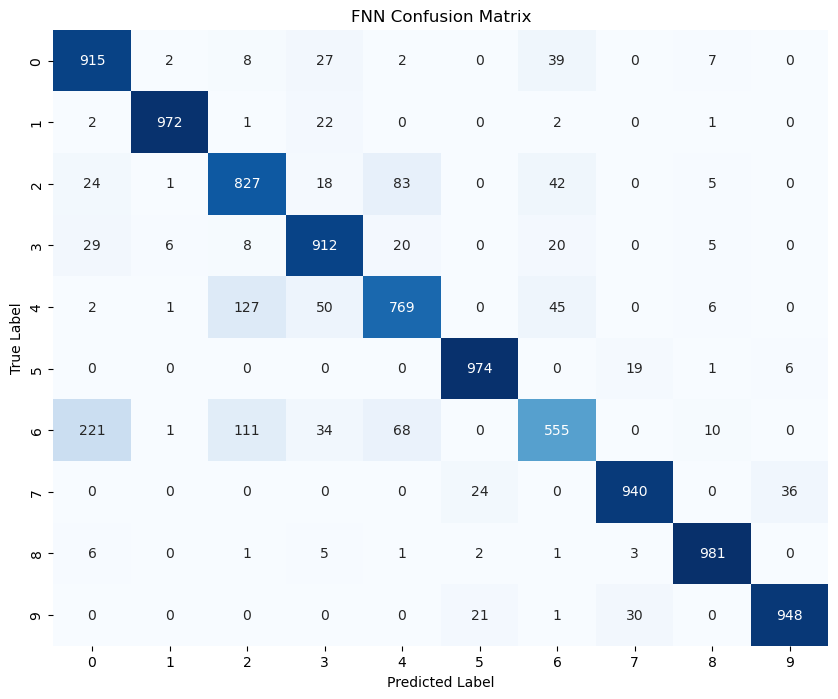

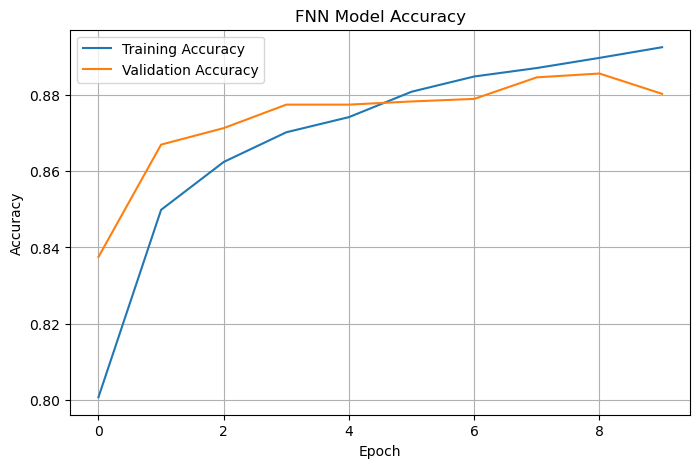

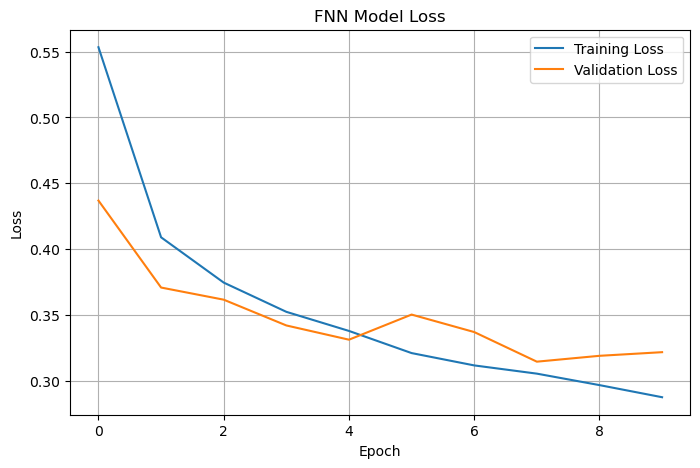



PART 2: CONVOLUTIONAL NEURAL NETWORK

Original CNN Training Data Shape: (60000, 28, 28)
Original CNN Testing Data Shape: (10000, 28, 28)

Reshaped CNN Training Data Shape: (60000, 28, 28, 1)
Reshaped CNN Testing Data Shape: (10000, 28, 28, 1)

--- CNN MODEL SUMMARY ---


C:\Users\Lenovo\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- TRAINING CNN MODEL ---

--- EVALUATING CNN MODEL ---

CNN Test Loss: 0.0257
CNN Test Accuracy: 0.9934

--- CNN CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


--- CNN CONFUSION MATRIX ---


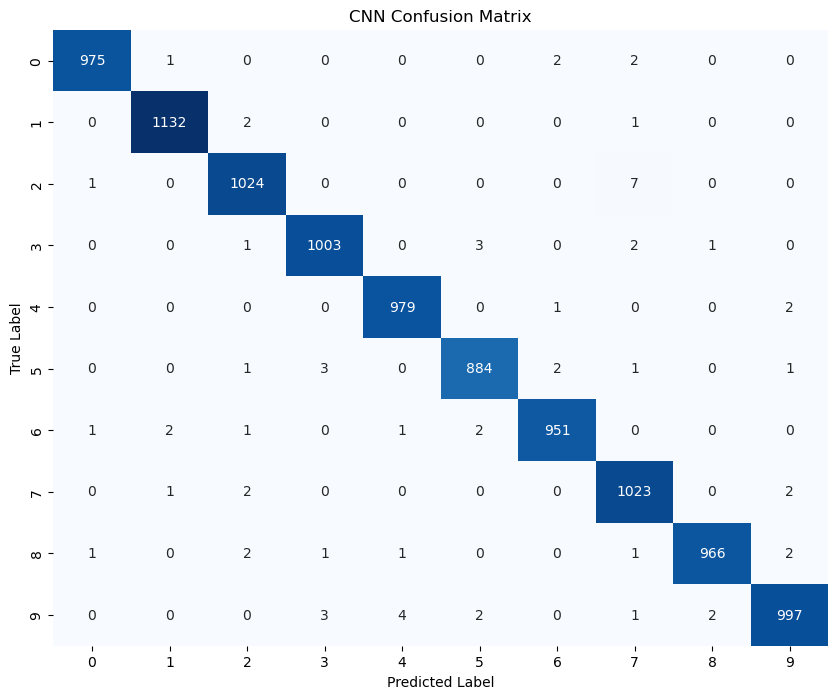

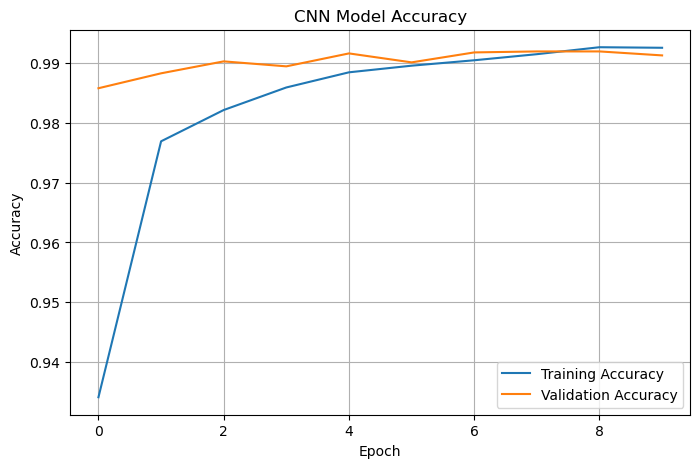

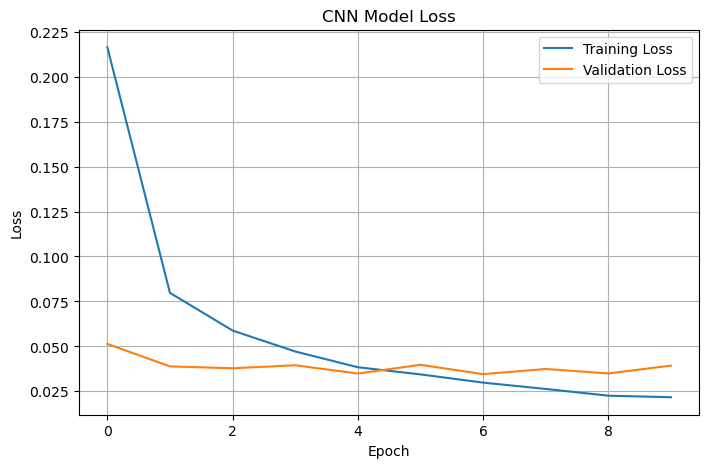


--- SAMPLE CNN PREDICTIONS ---


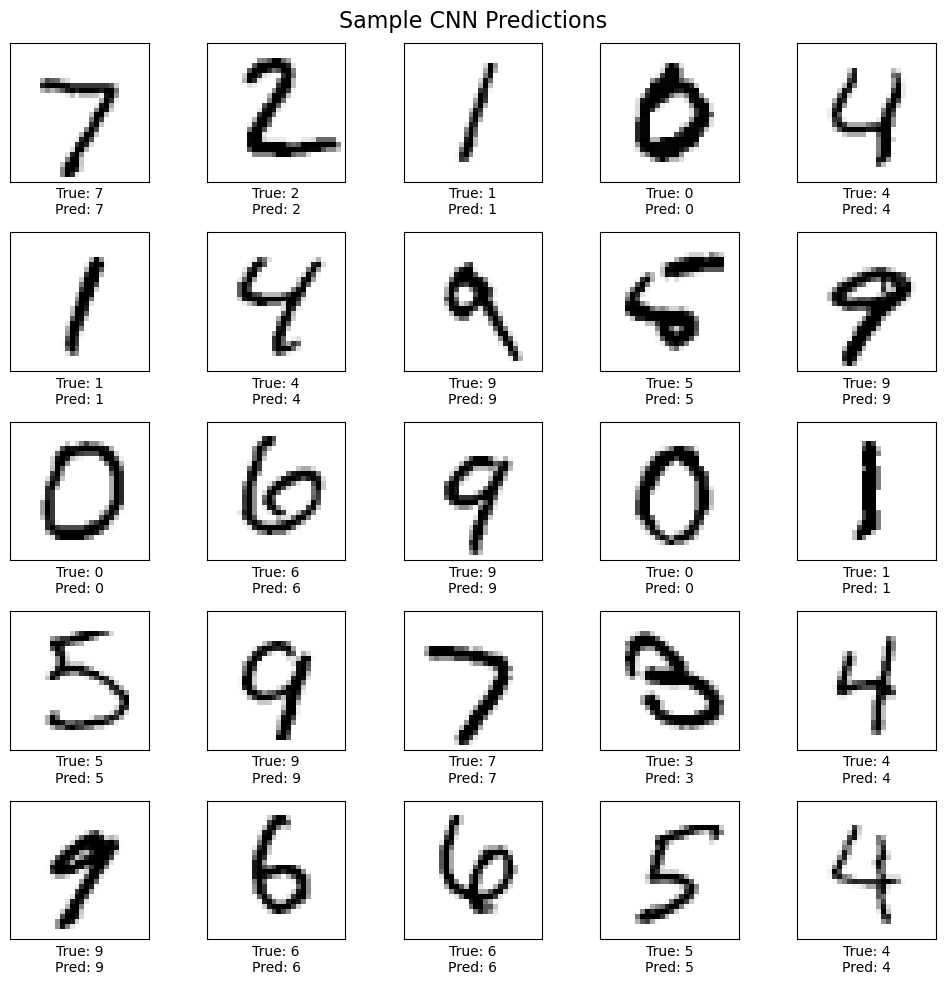



FNN vs CNN
FNN Test Accuracy: 0.8793
CNN Test Accuracy: 0.9934


EXPERIMENT 6 COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# EXPERIMENT 6
# FEEDFORWARD AND CONVOLUTIONAL NEURAL NETWORKS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.datasets import mnist, fashion_mnist

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns


# ============================================================
# BASIC SETTINGS
# ============================================================

tf.keras.utils.disable_interactive_logging()

print("=" * 60)
print("EXPERIMENT 6")
print("FEEDFORWARD AND CONVOLUTIONAL NEURAL NETWORKS")
print("=" * 60)


# ============================================================
# PART 1: FEEDFORWARD NEURAL NETWORK
# DATASET: FASHION-MNIST
# ============================================================

print("\n")
print("=" * 60)
print("PART 1: FEEDFORWARD NEURAL NETWORK")
print("=" * 60)


# ------------------------------------------------------------
# 1. Load Fashion-MNIST Dataset
# ------------------------------------------------------------

(x_train_fnn, y_train_fnn), (x_test_fnn, y_test_fnn) = \
    fashion_mnist.load_data()

print("\nOriginal FNN Training Data Shape:",
      x_train_fnn.shape)

print("Original FNN Testing Data Shape:",
      x_test_fnn.shape)


# ------------------------------------------------------------
# 2. Flatten Images
# 28 x 28 = 784
# ------------------------------------------------------------

x_train_fnn_flat = x_train_fnn.reshape(
    -1, 28 * 28
)

x_test_fnn_flat = x_test_fnn.reshape(
    -1, 28 * 28
)


# ------------------------------------------------------------
# 3. Normalize Pixel Values
# ------------------------------------------------------------

x_train_fnn_norm = x_train_fnn_flat / 255.0
x_test_fnn_norm = x_test_fnn_flat / 255.0

print("\nFlattened FNN Training Data Shape:",
      x_train_fnn_norm.shape)

print("Flattened FNN Testing Data Shape:",
      x_test_fnn_norm.shape)


# ============================================================
# 4. BUILD FNN MODEL
# ============================================================

model_fnn = keras.Sequential([

    layers.Dense(
        128,
        activation="relu",
        input_shape=(784,)
    ),

    layers.Dropout(0.2),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])


# ============================================================
# 5. COMPILE FNN MODEL
# ============================================================

model_fnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("\n--- FNN MODEL SUMMARY ---")

model_fnn.summary()


# ============================================================
# 6. TRAIN FNN MODEL
# ============================================================

print("\n--- TRAINING FNN MODEL ---")

history_fnn = model_fnn.fit(
    x_train_fnn_norm,
    y_train_fnn,
    epochs=10,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# 7. EVALUATE FNN MODEL
# ============================================================

print("\n--- EVALUATING FNN MODEL ---")

loss_fnn, accuracy_fnn = model_fnn.evaluate(
    x_test_fnn_norm,
    y_test_fnn,
    verbose=0
)

print("\nFNN Test Loss:",
      round(loss_fnn, 4))

print("FNN Test Accuracy:",
      round(accuracy_fnn, 4))


# ============================================================
# 8. FNN PREDICTIONS
# ============================================================

y_pred_fnn = np.argmax(
    model_fnn.predict(
        x_test_fnn_norm,
        verbose=0
    ),
    axis=-1
)


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\n--- FNN CLASSIFICATION REPORT ---")

print(
    classification_report(
        y_test_fnn,
        y_pred_fnn
    )
)


# ============================================================
# 10. FNN CONFUSION MATRIX
# ============================================================

print("\n--- FNN CONFUSION MATRIX ---")

cm_fnn = confusion_matrix(
    y_test_fnn,
    y_pred_fnn
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_fnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


# ============================================================
# 11. FNN ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_fnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("FNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 12. FNN LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_fnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("FNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# PART 2: CONVOLUTIONAL NEURAL NETWORK
# DATASET: MNIST
# ============================================================

print("\n")
print("=" * 60)
print("PART 2: CONVOLUTIONAL NEURAL NETWORK")
print("=" * 60)


# ------------------------------------------------------------
# 1. Load MNIST Dataset
# ------------------------------------------------------------

(x_train_cnn, y_train_cnn), (x_test_cnn, y_test_cnn) = \
    mnist.load_data()

print("\nOriginal CNN Training Data Shape:",
      x_train_cnn.shape)

print("Original CNN Testing Data Shape:",
      x_test_cnn.shape)


# ------------------------------------------------------------
# 2. Add Channel Dimension
# 28 x 28 -> 28 x 28 x 1
# ------------------------------------------------------------

x_train_cnn = x_train_cnn.reshape(
    x_train_cnn.shape[0],
    28,
    28,
    1
)

x_test_cnn = x_test_cnn.reshape(
    x_test_cnn.shape[0],
    28,
    28,
    1
)


# ------------------------------------------------------------
# 3. Normalize Images
# ------------------------------------------------------------

x_train_cnn = x_train_cnn.astype("float32") / 255.0
x_test_cnn = x_test_cnn.astype("float32") / 255.0

print("\nReshaped CNN Training Data Shape:",
      x_train_cnn.shape)

print("Reshaped CNN Testing Data Shape:",
      x_test_cnn.shape)


# ============================================================
# 4. BUILD CNN MODEL
# ============================================================

num_classes_cnn = 10

model_cnn = keras.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        num_classes_cnn,
        activation="softmax"
    )
])


# ============================================================
# 5. COMPILE CNN MODEL
# ============================================================

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("\n--- CNN MODEL SUMMARY ---")

model_cnn.summary()


# ============================================================
# 6. TRAIN CNN MODEL
# ============================================================

print("\n--- TRAINING CNN MODEL ---")

history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train_cnn,
    epochs=10,
    validation_split=0.1,
    verbose=1
)


# ============================================================
# 7. EVALUATE CNN MODEL
# ============================================================

print("\n--- EVALUATING CNN MODEL ---")

loss_cnn, accuracy_cnn = model_cnn.evaluate(
    x_test_cnn,
    y_test_cnn,
    verbose=0
)

print("\nCNN Test Loss:",
      round(loss_cnn, 4))

print("CNN Test Accuracy:",
      round(accuracy_cnn, 4))


# ============================================================
# 8. CNN PREDICTIONS
# ============================================================

y_pred_cnn = np.argmax(
    model_cnn.predict(
        x_test_cnn,
        verbose=0
    ),
    axis=-1
)


# ============================================================
# 9. CNN CLASSIFICATION REPORT
# ============================================================

print("\n--- CNN CLASSIFICATION REPORT ---")

print(
    classification_report(
        y_test_cnn,
        y_pred_cnn
    )
)


# ============================================================
# 10. CNN CONFUSION MATRIX
# ============================================================

print("\n--- CNN CONFUSION MATRIX ---")

cm_cnn = confusion_matrix(
    y_test_cnn,
    y_pred_cnn
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


# ============================================================
# 11. CNN ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 12. CNN LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 13. SAMPLE CNN PREDICTIONS
# ============================================================

print("\n--- SAMPLE CNN PREDICTIONS ---")

class_names = [str(i) for i in range(10)]

plt.figure(figsize=(10, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(
        x_test_cnn[i].reshape(28, 28),
        cmap=plt.cm.binary
    )

    true_label = y_test_cnn[i]
    predicted_label = y_pred_cnn[i]

    plt.xlabel(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}"
    )


plt.suptitle(
    "Sample CNN Predictions",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# FINAL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("FNN vs CNN")
print("=" * 60)

print(
    f"FNN Test Accuracy: {accuracy_fnn:.4f}"
)

print(
    f"CNN Test Accuracy: {accuracy_cnn:.4f}"
)

print("\n")
print("=" * 60)
print("EXPERIMENT 6 COMPLETED SUCCESSFULLY")
print("=" * 60)